In [2]:
import torch
import json
import matplotlib.pyplot as plt
import numpy as np

 Label     R²  SMAPE (%)       RMSE
  BRAM  0.276     53.950     34.004
   DSP  0.124     88.800    829.608
    FF  0.167     53.534  79149.977
   LUT  0.446     48.571  60019.840
Cycles  0.054     78.135 830783.000
    II  0.062     94.565 827664.562
  URAM -0.018      8.808      2.212


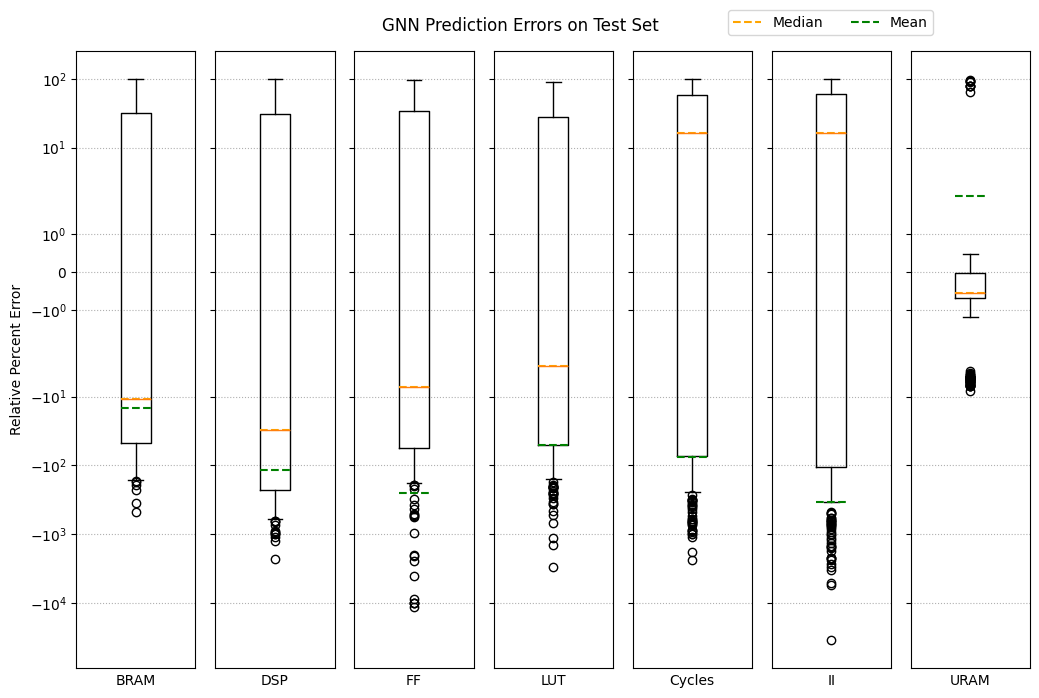

In [ ]:
def labels_translator(labels: list[str]) -> list[str]:
    rosetta_stone = {
        "lut": "LUT",
        "ff": "FF",
        "dsp": "DSP",
        "bram": "BRAM",
        "uram": "URAM",
        "cycles_max": "Cycles",
        "cycles_min": "Cycles",
        "interval_max": "II",
        "interval_min": "II",
    }
    return [rosetta_stone[label] for label in labels]




        


from ll_hls4ml.io.schema import LABEL_KEYS
from ll_hls4ml.training.targets import to_luts

kaggle_results_path = "/home/brend/projects/kaggle_runs/full_ind_vs_trans/"
kernel_types = ["2layer", "3layer", "conv1d", "conv2d", "dense_latency", "dense_resource", "exemplar", "rule4ml"]
kernel_type = "dense_resource"

training_history = {}
with open(f"{kaggle_results_path}/training_histories_{kernel_type}.json", "r") as f:
    training_history = json.load(f)

y_means, y_stds = torch.tensor(training_history["y_means"]), torch.tensor(training_history["y_stds"])
lut_preds = to_luts(torch.tensor(training_history["best_val_preds"]), y_means, y_stds)
lut_targets = to_luts(torch.tensor(training_history["best_val_targets"]), y_means, y_stds)

ordering = ["BRAM", "DSP", "FF", "LUT", "Cycles", "II", "URAM"]
wahls4ml_metrics(lut_preds, lut_targets, labels_translator(LABEL_KEYS), ordering)
rpe_box_plots(lut_preds, lut_targets, labels_translator(LABEL_KEYS), ordering)


In [83]:
from json import load
from pathlib import Path
import torch
from torch import nn

from ll_hls4ml.data.dataset import HeteroGraphDataset
from ll_hls4ml.data.splits import random_train_val_split
from ll_hls4ml.data.vocab import load_vocab
from ll_hls4ml.models.registry import build
from ll_hls4ml.training import make_loader
from ll_hls4ml.training.distributed import cleanup_ddp, is_main_process, setup_from_env
from ll_hls4ml.training.loops import _json_converter, fit, _persist_on_cpu, validate_one_epoch, _broadcast_target_stats

device = torch.device("cuda")
tensor_dir = Path("../../data/tensors/")
vocab, max_pos, _ = load_vocab(tensor_dir / "vocab.json")
vocab_sizes = {k: len(v) for k, v in vocab.items()}

# max_per_kernel_type =  {
#     "2layer":         200,
#     "3layer":         300,
#     "conv1d":         300,
#     "conv2d":         300,
#     "dense_latency":  300,
#     "dense_resource": 300,
#     "exemplar":       300,
#     "rule4ml":        300,
#   }

val_frac = 0.2
test_frac = 0.1
ds = HeteroGraphDataset(tensor_dir, types=None, max_per_type=None, silent=False)
train_val_ds, test_ds = random_train_val_split(ds, val_fraction=test_frac, seed=42)
train_ds, val_ds = random_train_val_split(train_val_ds, val_fraction=val_frac, seed=42)

batch_size = 2
train_loader = make_loader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = make_loader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = make_loader(test_ds, batch_size=batch_size, shuffle=False)

model = build(
    "rgcn",
    node_vocab_sizes=vocab_sizes,
    edge_pos_vocab_size=max_pos,
    hidden_dim=64,
    num_layers=5,
    dropout=0.3,
).to(device)

load_model_path = Path("../../kaggle_runs/9/artifacts/models/trans_vs_ind_test_model.pt")
if load_model_path:
    state_dict = torch.load(load_model_path)
    model.load_state_dict(state_dict)
    print(f"Loading {load_model_path}")
model.eval()


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.HuberLoss(reduction="mean", delta=1.0)
y_means, y_stds = _broadcast_target_stats(train_loader.dataset, device, distributed=False)


print("Evaluating on train set...")
train_loss, train_preds, train_targets, _, _ = validate_one_epoch(
    model, train_loader, criterion, device, y_means, y_stds
)
print(f"{train_loss:.3f}")

print("Evaluating on val set...")
val_loss, val_preds, val_targets, _, _ = validate_one_epoch(
    model, val_loader, criterion, device, y_means, y_stds
)
print(f"{val_loss:.3f}")

print("Evaluating on test set...")
test_loss, test_preds, test_targets, _, _ = validate_one_epoch(
    model, test_loader, criterion, device, y_means, y_stds
)
print(f"{test_loss:.3f}")

Indexed 1426 graphs across 9 type(s)
  2layer: 200
    avg size: 0.66 MB
    total size: 132.08 MB
  3layer: 200
    avg size: 0.72 MB
    total size: 144.95 MB
  conv1d: 173
    avg size: 5.33 MB
    total size: 922.18 MB
  conv2d: 106
    avg size: 5.44 MB
    total size: 576.12 MB
  dense_latency: 140
    avg size: 3.36 MB
    total size: 471.00 MB
  dense_resource: 107
    avg size: 3.45 MB
    total size: 368.93 MB
  exemplar: 300
    avg size: 1.51 MB
    total size: 452.00 MB
  rule4ml: 200
    avg size: 2.06 MB
    total size: 412.56 MB


/home/brend/projects/ll-hls4ml/src/ll_hls4ml/models/rgcn.py:45: UserWarning: There exist node types ({'constant'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.conv = HeteroConv(


Loading ../../kaggle_runs/9/artifacts/models/trans_vs_ind_test_model.pt
Evaluating on train set...
0.118
Evaluating on val set...
0.132
Evaluating on test set...
0.100


 Label    R²  SMAPE (%)       RMSE
  BRAM 0.239     62.307     17.453
   DSP 0.001     84.776    518.188
    FF 0.669     43.350  26215.201
   LUT 0.524     47.303  56936.328
Cycles 0.364     82.705 249467.906
    II 0.399     91.973 271496.531
  URAM 0.042      6.696      0.550


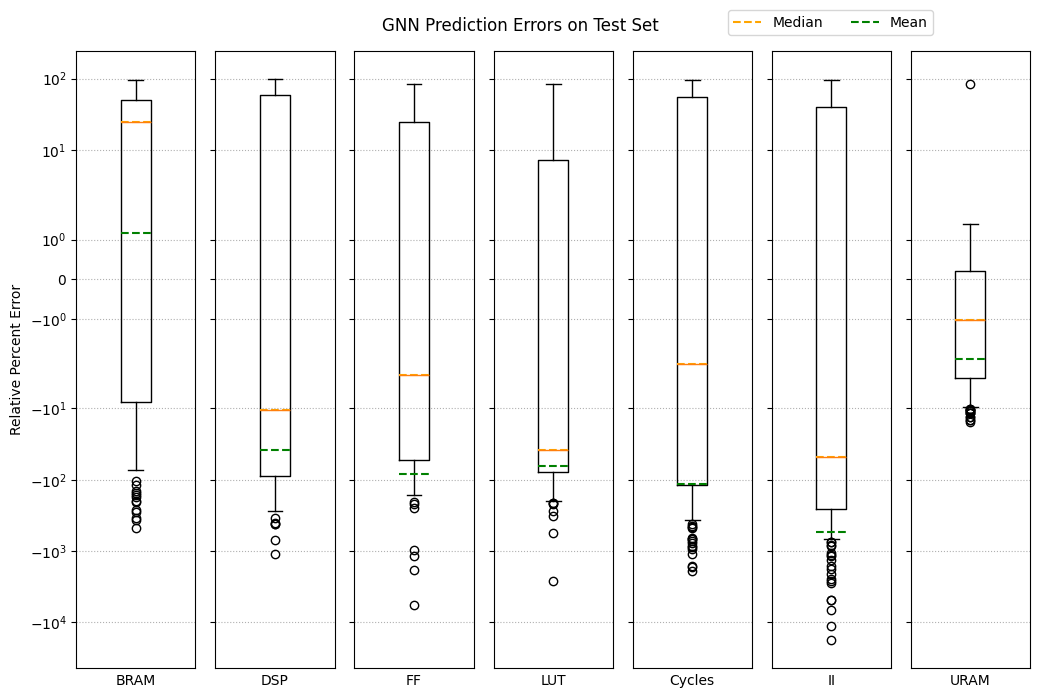

In [ ]:
lut_preds = to_luts(torch.tensor(test_preds).cpu(), y_means.cpu(), y_stds.cpu())
lut_targets = to_luts(torch.tensor(test_targets).cpu(), y_means.cpu(), y_stds.cpu())

ordering = ["BRAM", "DSP", "FF", "LUT", "Cycles", "II", "URAM"]
wahls4ml_metrics(lut_preds, lut_targets, labels_translator(LABEL_KEYS), ordering)
rpe_box_plots(lut_preds, lut_targets, labels_translator(LABEL_KEYS), ordering)
